# ArUco 보드 보정

1. 실제 촬영 이미지에서 마커 6개가 검출되는가
2. 보드가 휘어 있어도 칸 5개를 정면 이미지로 펼 수 있는가
3. 잘라낸 칸에 테두리가 섞이거나 글자가 잘리지 않는가

```
1280x720 프레임
  -> 마커 검출 (DICT_4X4_50, id 0..5)
  -> 보드 좌표계 수립
  -> 칸마다 piecewise homography 로 역방향 매핑
  -> 칸당 112x112 RGB (24비트)                 <- 여기까지 PS
  ------------------------------------------------------------
  -> luma, 28x28, 반전, threshold             <- PL, img_preprocess.v
```

- ArUco Marker
  - openCV `DICT_4X4_50`에 50종이 미리 정해진 4x4 흑백 격자 패턴으로, ID와 위치를 보유해 비트가 조금 틀려도 ID를 복구 가능
  - 검출기는 ID와 꼭짓점 4개의 이미지 좌표(픽셀)을 반환
- Homograpy 
  - 원근 왜곡(비스듬한 평면)을 정면으로 펴주는 평면에서 평면의 전환
  - 화이트보드의 마커 6개로 진행하여 사진마다 매번 구해야함
- Calibration
  - 렌즈가 직선을 곡선으로 휘게 만든 왜곡을 보정함
  - 크기를 정확히 알 수 있는 ChArUco 판 사진으로 진행해 고정된 카메라 고유값을 구해 놓으면, 동일 해상도에서는 이후에는 매번 구하지 않아도 됨

| | Marker | Homogarpy | Calibration |
| --- | --- | --- | --- |
| 하는 일 | 위치 기준점 제공 | 원근 되돌림 | 렌즈 휘어짐 되돌림 |
| 입력 | 사진 | 마커 4개의 대응 | ChArUco 판 사진 여러 장 |
| 구하는 때 | 프레임마다 | 프레임마다 | 카메라당 한 번 |
| 결과 | ID와 꼭짓점 좌표 | 3x3 행렬 | `K`와 왜곡 계수 |

## 0. 준비

import, 노트북 폴더(`HERE`), 시험 사진 목록(`IMAGES`)

In [1]:
import os, glob, json
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("opencv", cv2.__version__)

HERE = os.getcwd()
IMG_DIR = os.path.join(HERE, "images")
OUT_DIR = os.path.join(HERE, "out")
os.makedirs(OUT_DIR, exist_ok=True)

IMAGES = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
print(len(IMAGES), "images")
for p in IMAGES:
    print("   ", os.path.basename(p))

opencv 5.0.0
6 images
    aru_test_img_apple.png
    aru_test_img_hello.png
    aru_test_img_line.png
    aru_test_img_world-1.png
    aru_test_img_world-2.png
    aru_test_img_world-3.png


## 1. 설정값

- `BOARD` 는 화이트보드의 기하 구조
- 좌표계는 칸 단위
     - `x` : 화이트보드 왼쪽 끝이 0, 오른쪽 끝이 5. 칸 하나가 1
     - `y` : 칸 줄의 위쪽 끝이 0, 아래쪽 끝이 1
     - 마커 6개의 중심 위치를 상수로 정의함

```
   id0              id1             id2        <- y = MARK_Y_TOP
   +------+------+------+------+------+
   | 0    | 1    | 2    | 3    | 4    |        <- y = 0 .. 1
   +------+------+------+------+------+
   id3              id4             id5        <- y = MARK_Y_BOT
   x=0                              x=5
```

In [2]:
# 보드 기하
NUM_CELLS   = 5

MARK_X_SIDE = 0.2365   # 좌우 끝 마커 중심 x (칸 단위, 보드 왼쪽 끝 = 0)
MARK_Y_TOP  = -0.1628  # 위쪽 마커 중심 y, 칸 줄 위라 음수
MARK_Y_BOT  =  1.1393

# id -> 보드 좌표 마커 중심
BOARD = {
    0: (MARK_X_SIDE,              MARK_Y_TOP),
    1: (NUM_CELLS / 2.0,          MARK_Y_TOP),
    2: (NUM_CELLS - MARK_X_SIDE,  MARK_Y_TOP),
    3: (MARK_X_SIDE,              MARK_Y_BOT),
    4: (NUM_CELLS / 2.0,          MARK_Y_BOT),
    5: (NUM_CELLS - MARK_X_SIDE,  MARK_Y_BOT),
}

TOP_IDS, BOT_IDS = (0, 1, 2), (3, 4, 5)
SEAM_X = NUM_CELLS / 2.0          # 좌우 조각 경계

# 잘라내기
OUT_N  = 112     # PS 가 PL 로 보내는 칸 한 변(px)
INSET  = 0.055   # 칸 위아래 여백 (칸 높이 대비 비율)

# 칸 좌우 범위 (검은 선 안쪽 가장자리, 보드 좌표)
# 칸마다 폭이 달라 칸별로 둠, 5절 '칸 좌우 범위 재측정' 셀에서 측정
CELL_X   = [(0.095, 0.956), (1.046, 1.987), (2.072, 2.970), (3.073, 3.946), (4.056, 4.915)]
MARGIN_X = 0.025   # 검은 선에서 더 물러나는 폭

ARUCO_DICT = cv2.aruco.DICT_4X4_50

## 1-1. Camera Calibration

| 값 | 뜻 |
| --- | --- |
| `K` (fx, fy, cx, cy) | 초점거리와 광축 위치 (픽셀) |
| `dist` (k1, k2, p1, p2, k3) | 렌즈 왜곡 계수. k3 는 0 으로 고정 |

### 판 PDF 만들기

`board_image`, `pdf_text`, `build_pdf` 로 ChArUco 판을 A4 PDF 로 저장하고 미리보기 표시

wrote /Users/mumallaeng/repo/activity/LightLetter-aruco-worktree/tb/aruco_crop/print/charuco_board_a4.pdf
board 177.8 x 254.0 mm on A4


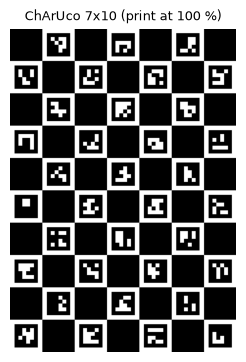

In [3]:
import os
import zlib

import cv2

# 캘리브레이션 판 사양. 캘리브레이션 셀의 CB_* 상수와 같은 값이어야 한다
SQ_X, SQ_Y = 7, 10
SQUARE_PX, MARKER_PX = 300, 216     # 300 dpi 에서 1 inch, 0.72 inch
DPI = 300
DICT = cv2.aruco.DICT_4X4_50

BOARD_PDF = os.path.join(HERE, "print", "charuco_board_a4.pdf")

PT = 72.0                            # PDF 한 단위 = 1/72 inch
A4_W, A4_H = 595.276, 841.890


def board_image():
    """ChArUco 캘리브레이션 판을 흑백 이미지로 전환"""
    board = cv2.aruco.CharucoBoard((SQ_X, SQ_Y), SQUARE_PX, MARKER_PX,
                                   cv2.aruco.getPredefinedDictionary(DICT))
    return board.generateImage((SQ_X * SQUARE_PX, SQ_Y * SQUARE_PX), marginSize=0, borderBits=1)


def pdf_text(x, y, size, s):
    """PDF 안에 글자 삽입"""
    return "BT /F1 %d Tf %.2f %.2f Td (%s) Tj ET\n" % (size, x, y, s)


def build_pdf(path):
    """판 이미지를 A4 PDF 한 장으로 저장

    return: width_mm, height_mm
    """
    img = board_image()
    h, w = img.shape
    wpt, hpt = w / DPI * PT, h / DPI * PT
    x = (A4_W - wpt) / 2.0
    y = A4_H - 26 - hpt

    mm = PT / 25.4
    rx = (A4_W - 100 * mm) / 2.0
    ry = 34.0
    ruler = "0 G 0.6 w\n%.2f %.2f m %.2f %.2f l S\n" % (rx, ry, rx + 100 * mm, ry)
    for t in range(0, 101, 10):
        tick = 5 if t % 50 == 0 else 3
        ruler += "%.2f %.2f m %.2f %.2f l S\n" % (rx + t * mm, ry, rx + t * mm, ry + tick)

    content = ("1 g 0 0 %.3f %.3f re f 0 g\n" % (A4_W, A4_H)          # 흰 배경
               + "q %.2f 0 0 %.2f %.2f %.2f cm /Im0 Do Q\n" % (wpt, hpt, x, y)
               + "0 g\n"
               + pdf_text(x, y - 16, 9, "ChArUco %dx%d   square 25.4 mm   marker 18.288 mm   DICT_4X4_50" % (SQ_X, SQ_Y))
               + pdf_text(x, y - 28, 9, "print at 100 %, no fit to page. the ruler below must measure 100 mm.")
               + ruler
               + pdf_text(rx + 100 * mm + 6, ry - 3, 8, "100 mm"))

    data = zlib.compress(img.tobytes(), 9)
    objs = [
        b"<< /Type /Catalog /Pages 2 0 R >>",
        b"<< /Type /Pages /Kids [3 0 R] /Count 1 >>",
        (b"<< /Type /Page /Parent 2 0 R /MediaBox [0 0 %.3f %.3f] /Contents 4 0 R "
         b"/Resources << /XObject << /Im0 5 0 R >> /Font << /F1 6 0 R >> >> >>") % (A4_W, A4_H),
        b"<< /Length %d >>\nstream\n" % len(content) + content.encode("ascii") + b"endstream",
        (b"<< /Type /XObject /Subtype /Image /Width %d /Height %d /ColorSpace /DeviceGray "
         b"/BitsPerComponent 8 /Filter /FlateDecode /Length %d >>\nstream\n") % (w, h, len(data))
        + data + b"\nendstream",
        b"<< /Type /Font /Subtype /Type1 /BaseFont /Helvetica >>",
    ]
    out = bytearray(b"%PDF-1.4\n")
    offs = []
    for i, o in enumerate(objs):
        offs.append(len(out))
        out += b"%d 0 obj\n" % (i + 1) + o + b"\nendobj\n"
    xref = len(out)
    out += b"xref\n0 %d\n0000000000 65535 f \n" % (len(objs) + 1)
    for o in offs:
        out += b"%010d 00000 n \n" % o
    out += b"trailer\n<< /Size %d /Root 1 0 R >>\nstartxref\n%d\n%%%%EOF\n" % (len(objs) + 1, xref)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        f.write(out)
    return wpt / PT * 25.4, hpt / PT * 25.4

wmm, hmm = build_pdf(BOARD_PDF)
print("wrote", BOARD_PDF)
print("board %.1f x %.1f mm on A4" % (wmm, hmm))

plt.figure(figsize=(3, 4.2))
plt.imshow(board_image(), cmap="gray")
plt.axis("off")
plt.title("ChArUco %dx%d (print at 100 %%)" % (SQ_X, SQ_Y), fontsize=9)
plt.show()

### Calibration 도구

설정값과 함수 모음, 정의만 하고 실행은 다음 셀에서 함

순서: `find_corners` -> `solve` -> `heldout_error` -> `calibrate` -> `save_calib` / `load_calib` -> `load_frame`

In [4]:
CALIB_DIR  = os.path.join(HERE, "calib")
CALIB_JSON = os.path.join(CALIB_DIR, "camera.json")
os.makedirs(CALIB_DIR, exist_ok=True)

CB_SQUARES_X, CB_SQUARES_Y = 7, 10
CB_SQUARE_MM = 25.4
CB_MARKER_MM = 18.288
CB_DICT      = cv2.aruco.DICT_4X4_50

if "SQ_X" in globals():                                       # 판 생성 셀 값이 서로 맞는지 확인
    assert (CB_SQUARES_X, CB_SQUARES_Y) == (SQ_X, SQ_Y),      "판 칸 수 비교"
    assert abs(CB_SQUARE_MM - SQUARE_PX / DPI * 25.4) < 1e-6, "칸 크기 비교"
    assert abs(CB_MARKER_MM - MARKER_PX / DPI * 25.4) < 1e-6, "마커 크기 비교"
    assert CB_DICT == DICT,                                   "마커 사전 비교"

FRAME_W, FRAME_H = 1280, 720

# k3 와 접선 왜곡(p1, p2)은 0 으로 고정 
# 사진 64 장으로 접선 항을 풀어 봤을 때 p1, p2 가 0.001 미만이었고 오차도 그대로 -> 왜곡 계수를 k1, k2 두 개로 줄임
CALIB_FLAGS = cv2.CALIB_FIX_K3 | cv2.CALIB_ZERO_TANGENT_DIST
MIN_CORNERS = 12  
MIN_PHOTOS  = 8   


def as_frame(bgr):
    """화면 캡처 이미지(1282x752)에서 창 테두리를 잘라 내고 카메라 영상 1280x720 남김
    """
    h, w = bgr.shape[:2]
    if (w, h) == (FRAME_W + 2, FRAME_H + 32):
        return bgr[31:31 + FRAME_H, 1:1 + FRAME_W]
    return bgr


def find_corners(paths):
    """사진마다 ChArUco 판의 모서리를 찾고, MIN_CORNERS개 미만인 사진은 건너뜀

    return: obj, img, used, skipped
    """
    board = cv2.aruco.CharucoBoard((CB_SQUARES_X, CB_SQUARES_Y), CB_SQUARE_MM, CB_MARKER_MM,
                                   cv2.aruco.getPredefinedDictionary(CB_DICT))
    detector = cv2.aruco.CharucoDetector(board)
    obj, img, used, skipped = [], [], [], []
    for p in paths:
        name = os.path.basename(p)
        g = cv2.cvtColor(as_frame(cv2.imread(p)), cv2.COLOR_BGR2GRAY)
        corners, ids, _, _ = detector.detectBoard(g)
        n = 0 if ids is None else len(ids)
        if n < MIN_CORNERS:
            skipped.append((name, n))
            continue
        o, i = board.matchImagePoints(corners, ids)
        obj.append(o)
        img.append(i)
        used.append(name)
    return obj, img, used, skipped


def solve(obj, img):
    """판 모서리 위치로 K, dist 계산 (사진별 재투영 오차 포함)

    return: rms, K, dist, per
    """
    rms, K_, dist_, rvecs, tvecs = cv2.calibrateCamera(
        obj, img, (FRAME_W, FRAME_H), None, None, flags=CALIB_FLAGS)
    per = []
    for o, i, rv, tv in zip(obj, img, rvecs, tvecs):
        pr, _ = cv2.projectPoints(o, rv, tv, K_, dist_)
        per.append(float(np.sqrt(((pr.reshape(-1, 2) - i.reshape(-1, 2)) ** 2).sum(1).mean())))
    return float(rms), K_, dist_.ravel(), per


def heldout_error(obj, img, frac=0.25, seed=0):
    """사진 일부를 빼고 계산해 빠진 사진에서 오차(px) 측정, 과적합 확인"""
    order = np.random.default_rng(seed).permutation(len(obj))
    n_test = max(1, int(round(len(obj) * frac)))
    test, train = order[:n_test], order[n_test:]
    if len(train) < MIN_PHOTOS:
        return None
    _, K_, dist_, _ = solve([obj[i] for i in train], [img[i] for i in train])
    err = []
    for i in test:
        ok, rv, tv = cv2.solvePnP(obj[i], img[i], K_, dist_)
        if not ok:
            continue
        pr, _ = cv2.projectPoints(obj[i], rv, tv, K_, dist_)
        err.append(np.sqrt(((pr.reshape(-1, 2) - img[i].reshape(-1, 2)) ** 2).sum(1).mean()))
    return float(np.mean(err)) if err else None


def calibrate(paths):
    """판 사진들로 calibration 실행

    return: dict(K, dist, rms, per_image, images, skipped, margins, grid, heldout)
    """
    obj, img, used, skipped = find_corners(paths)
    if len(used) < MIN_PHOTOS:
        raise RuntimeError("사용 가능한 사진 %d장 (최소 %d장)" % (len(used), MIN_PHOTOS))
    rms, K_, dist_, per = solve(obj, img)
    pts = np.vstack([i.reshape(-1, 2) for i in img])
    grid = np.histogram2d(pts[:, 1], pts[:, 0],
                          bins=[np.linspace(0, FRAME_H, 4), np.linspace(0, FRAME_W, 4)])[0].astype(int)
    margins = dict(left=int(pts[:, 0].min()), right=int(FRAME_W - 1 - pts[:, 0].max()),
                   top=int(pts[:, 1].min()), bottom=int(FRAME_H - 1 - pts[:, 1].max()))
    return dict(K=K_, dist=dist_, rms=rms, per_image=per, images=used, skipped=skipped,
                margins=margins, grid=grid, heldout=heldout_error(obj, img))


def save_calib(c):
    """camera.json에 calibration 결과 저장"""
    with open(CALIB_JSON, "w") as f:
        json.dump({"size": [FRAME_W, FRAME_H], "K": c["K"].tolist(),
                   "dist": [float(v) for v in c["dist"]],
                   "rms_px": c["rms"], "heldout_px": c["heldout"], "images": c["images"]}, f, indent=1)


def load_calib():
    """camera.json에서 K, dist 읽기 (없거나 해상도가 다르면 None)

    return: K, dist
    """
    if not os.path.exists(CALIB_JSON):
        return None, None
    with open(CALIB_JSON) as f:
        d = json.load(f)
    if list(d.get("size", [])) != [FRAME_W, FRAME_H]:
        print("camera.json 해상도 %s가 %dx%d와 달라 무시" % (d.get("size"), FRAME_W, FRAME_H))
        return None, None
    return np.array(d["K"]), np.array(d["dist"])


K, DIST = None, None
_MAPS = {}


def load_frame(path):
    """이미지 읽기, calibration 결과가 있으면 undistort 적용"""
    bgr = as_frame(cv2.imread(path))
    if K is None:
        return bgr
    h, w = bgr.shape[:2]
    if (w, h) not in _MAPS:
        _MAPS[(w, h)] = cv2.initUndistortRectifyMap(K, DIST, None, K, (w, h), cv2.CV_32FC1)
    mx, my = _MAPS[(w, h)]
    return cv2.remap(bgr, mx, my, cv2.INTER_LINEAR)

### Calibration 실행

`calib/` 사진으로 `calibrate` 실행, `camera.json` 저장, `describe` 로 결과 요약 출력, `K`, `DIST` 로드

In [5]:
CALIB_IMAGES = sorted(glob.glob(os.path.join(CALIB_DIR, "*.png")))


def describe(result):
    """calibration 결과 출력, 문제가 있으면 경고"""
    rms = result["rms"]
    verdict = "좋음" if rms < 0.5 else ("보통" if rms < 1.0 else "의심")   # 0.5 미만 좋음, 1.0 이상 의심
    print("사용 %d장, 건너뜀 %d장" % (len(result["images"]), len(result["skipped"])))
    for name, n in result["skipped"]:
        print("   모서리 %d개 건너뜀: %s" % (n, name))
    print("재투영 오차 rms %.3f px (%s)" % (rms, verdict))
    if result["heldout"] is not None:
        print("held-out 오차 %.3f px" % result["heldout"])

    per = np.array(result["per_image"])
    limit = max(1.5, 2.5 * float(np.median(per)))
    bad = [(result["images"][i], per[i]) for i in np.argsort(per)[::-1] if per[i] > limit]
    if bad:
        print("오차 큰 사진 (> %.2f px):" % limit)
        for name, e in bad:
            print("   %.2f px  %s" % (e, name))

    m = result["margins"]
    print("모서리가 안 닿은 가장자리 (px): 왼 %d, 오른 %d, 위 %d, 아래 %d"
          % (m["left"], m["right"], m["top"], m["bottom"]))
    print("모서리 수 (3x3, 위->아래 / 왼->오른)")
    for row in result["grid"]:
        print("   " + " ".join("%5d" % v for v in row))
    weak = [name for name, v, lim in (("왼쪽", m["left"], FRAME_W * 0.08), ("오른쪽", m["right"], FRAME_W * 0.08),
                                      ("위쪽", m["top"], FRAME_H * 0.08), ("아래쪽", m["bottom"], FRAME_H * 0.08))
            if v > lim]
    if weak:
        print("덜 덮은 가장자리: %s" % ", ".join(weak))


if CALIB_IMAGES:
    try:
        result = calibrate(CALIB_IMAGES)
    except RuntimeError as e:
        print("calibration 건너뜀:", e)
    else:
        save_calib(result)
        describe(result)

K, DIST = load_calib()
_MAPS.clear()

if K is None:
    print("calibration 결과 없음, undistort 건너뜀")
else:
    print()
    print("K =")
    print(np.round(K, 2))
    print("dist (k1, k2, p1, p2, k3) =", np.round(DIST, 5))
    mx, my = cv2.initUndistortRectifyMap(K, DIST, None, K, (FRAME_W, FRAME_H), cv2.CV_32FC1)
    spots = [("중앙", FRAME_W // 2, FRAME_H // 2),
             ("왼쪽 가운데", 0, FRAME_H // 2), ("오른쪽 가운데", FRAME_W - 1, FRAME_H // 2),
             ("왼쪽 위", 0, 0), ("오른쪽 아래", FRAME_W - 1, FRAME_H - 1)]
    print()
    print("undistort로 이동하는 거리 (px)")
    for n_, u, v in spots:
        print("   %-12s %6.1f" % (n_, np.hypot(mx[v, u] - u, my[v, u] - v)))

사용 64장, 건너뜀 0장
재투영 오차 rms 0.752 px (보통)
held-out 오차 0.686 px
오차 큰 사진 (> 1.50 px):
   1.89 px  스크린샷 2026-09-30 133839.png
   1.76 px  스크린샷 2026-09-30 133834.png
   1.54 px  스크린샷 2026-09-30 135402.png
모서리가 안 닿은 가장자리 (px): 왼 24, 오른 41, 위 57, 아래 66
모서리 수 (3x3, 위->아래 / 왼->오른)
     233   327   173
     435   895   443
     120   220   137
덜 덮은 가장자리: 아래쪽

K =
[[976.4    0.   642.36]
 [  0.   977.51 247.21]
 [  0.     0.     1.  ]]
dist (k1, k2, p1, p2, k3) = [-0.40055  0.14265  0.       0.       0.     ]

undistort로 이동하는 거리 (px)
   중앙              0.6
   왼쪽 가운데         98.0
   오른쪽 가운데        95.8
   왼쪽 위          112.7
   오른쪽 아래        159.9


### 결과 이미지

`pick_photos` 로 사진 6장을 골라 검출된 모서리를 표시

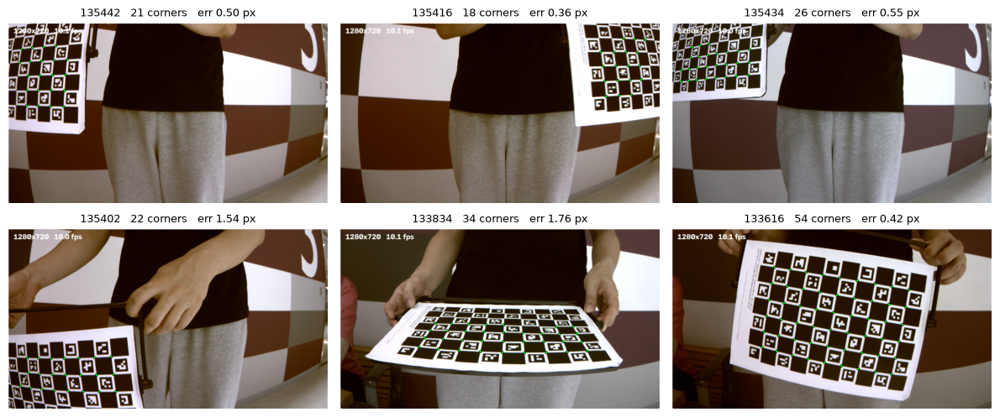

In [6]:
def short_name(name):
    """파일 이름 끝 6자리만 추출 (그림 제목용)"""
    return os.path.splitext(name)[0][-6:]


def pick_photos(obj_pts, img_pts, n=6):
    """판 위치와 기울기가 다른 사진 n장 선택"""
    centers = np.array([p.reshape(-1, 2).mean(axis=0) for p in img_pts])
    tilts = []
    for o, p in zip(obj_pts, img_pts):
        ok, rv, tv = cv2.solvePnP(o, p, K, DIST)
        tilts.append(np.degrees(np.arccos(abs(cv2.Rodrigues(rv)[0][2, 2]))))
    dist_to_center = np.hypot(centers[:, 0] - FRAME_W / 2, centers[:, 1] - FRAME_H / 2)
    picks = [int(np.argmin(centers[:, 0])), int(np.argmax(centers[:, 0])),
             int(np.argmin(centers[:, 1])), int(np.argmax(centers[:, 1])),
             int(np.argmax(tilts)), int(np.argmin(dist_to_center))]
    out = []
    for i in picks:
        if i not in out:
            out.append(i)
    for i in range(len(img_pts)):                 # 모자라면 아무 사진으로 채움
        if len(out) >= n:
            break
        if i not in out:
            out.append(i)
    return out[:n]


viz_ready = K is not None and "result" in globals()
if not viz_ready:
    print("캘리브레이션 결과가 없어 그림을 그리지 못한다")
else:
    viz_obj, viz_img, viz_names, _ = find_corners([os.path.join(CALIB_DIR, n) for n in result["images"]])
    viz_per = dict(zip(result["images"], result["per_image"]))
    viz_picks = pick_photos(viz_obj, viz_img)

    fig, ax = plt.subplots(2, 3, figsize=(12, 5.2))
    for a, i in zip(ax.ravel(), viz_picks):
        im = as_frame(cv2.imread(os.path.join(CALIB_DIR, viz_names[i]))).copy()
        for x, y in viz_img[i].reshape(-1, 2):
            cv2.circle(im, (int(round(x)), int(round(y))), 6, (0, 0, 0), -1)
            cv2.circle(im, (int(round(x)), int(round(y))), 4, (0, 255, 0), -1)
        a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        a.axis("off")
        a.set_title("%s   %d corners   err %.2f px" % (short_name(viz_names[i]), len(viz_img[i]), viz_per[viz_names[i]]),
                    fontsize=9)
    plt.tight_layout()
    plt.show()

### 왜곡 곡선, 격자, 어긋남 화살표

`k1`, `k2` 로 그린 왜곡 곡선, 곧은 격자의 변형, 예측과 측정 사이의 화살표 (그림 3개)

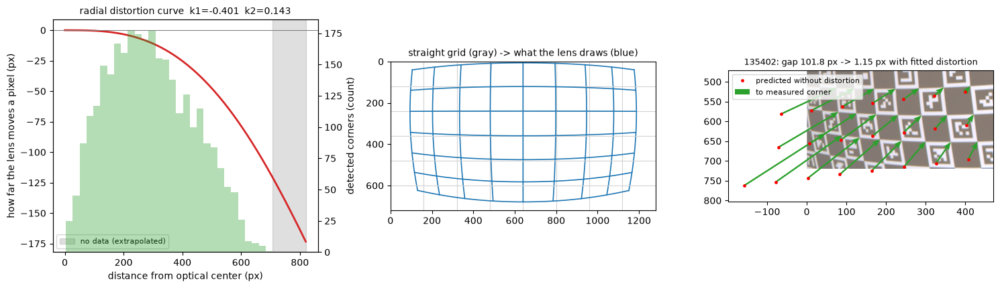

In [7]:
def distort_points(pts_px):
    """undistort된 이미지 좌표를 실제 사진 좌표로 변환"""
    xn = (pts_px[:, 0] - K[0, 2]) / K[0, 0]
    yn = (pts_px[:, 1] - K[1, 2]) / K[1, 1]
    ray = np.stack([xn, yn, np.ones_like(xn)], axis=1).reshape(-1, 1, 3)
    out, _ = cv2.projectPoints(ray, np.zeros(3), np.zeros(3), K, DIST)
    return out.reshape(-1, 2)


def prediction_gap(i):
    """사진 i의 '왜곡 없음' 예측과 '구한 왜곡' 예측이 측정 위치와 다른 정도

    return: no_dist, gap_no, gap_with
    """
    ok, rv, tv = cv2.solvePnP(viz_obj[i], viz_img[i], K, DIST)
    no_dist, _ = cv2.projectPoints(viz_obj[i], rv, tv, K, np.zeros(5))
    with_dist, _ = cv2.projectPoints(viz_obj[i], rv, tv, K, DIST)
    measured = viz_img[i].reshape(-1, 2)
    return no_dist.reshape(-1, 2), np.linalg.norm(measured - no_dist.reshape(-1, 2), axis=1), \
        np.linalg.norm(measured - with_dist.reshape(-1, 2), axis=1)


if not viz_ready:
    print("캘리브레이션 결과가 없어 그림을 그리지 못한다")
else:
    f = 0.5 * (K[0, 0] + K[1, 1])
    k1, k2 = DIST[0], DIST[1]
    r = np.linspace(0, 820, 200)                       # 광축까지 거리 (px)
    rn = r / f
    shift = f * rn * (k1 * rn ** 2 + k2 * rn ** 4)     # 렌즈가 옮기는 거리 (음수 = 안쪽)
    all_pts = np.vstack([p.reshape(-1, 2) for p in viz_img])
    radii = np.hypot(all_pts[:, 0] - K[0, 2], all_pts[:, 1] - K[1, 2])

    fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

    # 왜곡 곡선
    ax[0].plot(r, shift, color="tab:red", lw=2)
    ax[0].axhline(0, color="gray", lw=0.8)
    ax[0].axvspan(radii.max(), r.max(), color="gray", alpha=0.25, label="no data (extrapolated)")
    ax[0].set_xlabel("distance from optical center (px)")
    ax[0].set_ylabel("how far the lens moves a pixel (px)")
    ax[0].set_title("radial distortion curve  k1=%.3f  k2=%.3f" % (k1, k2), fontsize=10)
    twin = ax[0].twinx()
    twin.hist(radii, bins=30, color="tab:green", alpha=0.35)
    twin.set_ylabel("detected corners (count)")
    ax[0].legend(loc="lower left", fontsize=8)

    # 곧은 격자 -> 렌즈를 지난 모양
    steps = np.linspace(0, 1, 60)
    for u in range(0, FRAME_W + 1, 160):
        line = np.stack([np.full_like(steps, u), steps * FRAME_H], axis=1)
        ax[1].plot(line[:, 0], line[:, 1], color="lightgray", lw=0.8)
        d = distort_points(line)
        ax[1].plot(d[:, 0], d[:, 1], color="tab:blue", lw=1.2)
    for v in range(0, FRAME_H + 1, 120):
        line = np.stack([steps * FRAME_W, np.full_like(steps, v)], axis=1)
        ax[1].plot(line[:, 0], line[:, 1], color="lightgray", lw=0.8)
        d = distort_points(line)
        ax[1].plot(d[:, 0], d[:, 1], color="tab:blue", lw=1.2)
    ax[1].set_xlim(0, FRAME_W)
    ax[1].set_ylim(FRAME_H, 0)
    ax[1].set_aspect("equal")
    ax[1].set_title("straight grid (gray) -> what the lens draws (blue)", fontsize=10)

    # 어긋남 화살표 (가장 어긋난 사진)
    gaps = [prediction_gap(i)[1].mean() for i in viz_picks]
    best = viz_picks[int(np.argmax(gaps))]
    no_dist, gap_no, gap_with = prediction_gap(best)
    im = as_frame(cv2.imread(os.path.join(CALIB_DIR, viz_names[best])))
    measured = viz_img[best].reshape(-1, 2)
    ax[2].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB), alpha=0.55)
    ax[2].plot(no_dist[:, 0], no_dist[:, 1], "r.", ms=5, label="predicted without distortion")
    ax[2].quiver(no_dist[:, 0], no_dist[:, 1], measured[:, 0] - no_dist[:, 0], measured[:, 1] - no_dist[:, 1],
                 angles="xy", scale_units="xy", scale=1, color="tab:green", width=0.006,
                 headwidth=4, headlength=5, label="to measured corner")
    both = np.vstack([no_dist, measured])                 # 모서리 구간만 확대
    lo, hi = both.min(axis=0) - 40, both.max(axis=0) + 40
    ax[2].set_xlim(lo[0], hi[0])
    ax[2].set_ylim(hi[1], lo[1])
    ax[2].set_aspect("equal")
    ax[2].set_title("%s: gap %.1f px -> %.2f px with fitted distortion"
                    % (short_name(viz_names[best]), gap_no.mean(), gap_with.mean()), fontsize=9)
    ax[2].legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

## 2. 마커 검출

`detect()`
- 프레임 하나에서 id 별 마커 중심과 꼭짓점 return
- 중심을 쓰는 이유는 꼭짓점 하나보다 네 점의 평균이 노이즈에 덜 흔들리기 때문
- 꼭짓점은 나중에 마커 크기를 재는 데만 사용

### 마커 검출

`to_gray`, `detect` 정의, 시험 사진 6장의 검출 결과 표 출력

In [8]:
_detector = cv2.aruco.ArucoDetector(cv2.aruco.getPredefinedDictionary(ARUCO_DICT))

def to_gray(bgr):
    """마커 검출용 흑백 변환"""
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)


def detect(gray):
    """흑백 이미지에서 마커 검출

    return: {id: {'c', 'p', 'side'}}
    """
    corners, ids, _ = _detector.detectMarkers(gray)
    found = {}
    if ids is None:
        return found
    for i, cc in zip(ids.flatten(), corners):
        p = cc[0]
        side = (np.linalg.norm(p[1] - p[0]) + np.linalg.norm(p[2] - p[3])) / 2.0
        found[int(i)] = {"c": p.mean(axis=0), "p": p, "side": float(side)}
    return found


rows = []
for path in IMAGES:
    bgr = load_frame(path)
    gray = to_gray(bgr)
    f = detect(gray)
    sides = [v["side"] for v in f.values()]
    rows.append((os.path.basename(path), bgr.shape[1], bgr.shape[0],
                 sorted(f), min(sides) if sides else 0, max(sides) if sides else 0))

print("%-26s %-10s %-22s %s" % ("image", "size", "detected ids", "marker side px"))
for n, w, h, ids, lo, hi in rows:
    print("%-26s %4dx%-4d  %-22s %.0f .. %.0f  %s"
          % (n, w, h, str(ids), lo, hi, "" if len(ids) == 6 else "<- 일부 미검출"))

image                      size       detected ids           marker side px
aru_test_img_apple.png     1280x720   [0, 1, 2, 3, 4, 5]     37 .. 40  
aru_test_img_hello.png     1280x720   [0, 1, 2, 3, 4, 5]     36 .. 41  
aru_test_img_line.png      1280x720   [0, 1, 3, 4, 5]        37 .. 40  <- 일부 미검출
aru_test_img_world-1.png   1280x720   [1, 2, 3, 4]           35 .. 44  <- 일부 미검출
aru_test_img_world-2.png   1280x720   [0, 1, 2, 3, 4, 5]     37 .. 39  
aru_test_img_world-3.png   1280x720   [0, 1, 2, 3, 4, 5]     35 .. 41  


### 검출 결과 그림

`draw_markers`, `show` 정의, 검출된 마커를 이미지 위에 표시

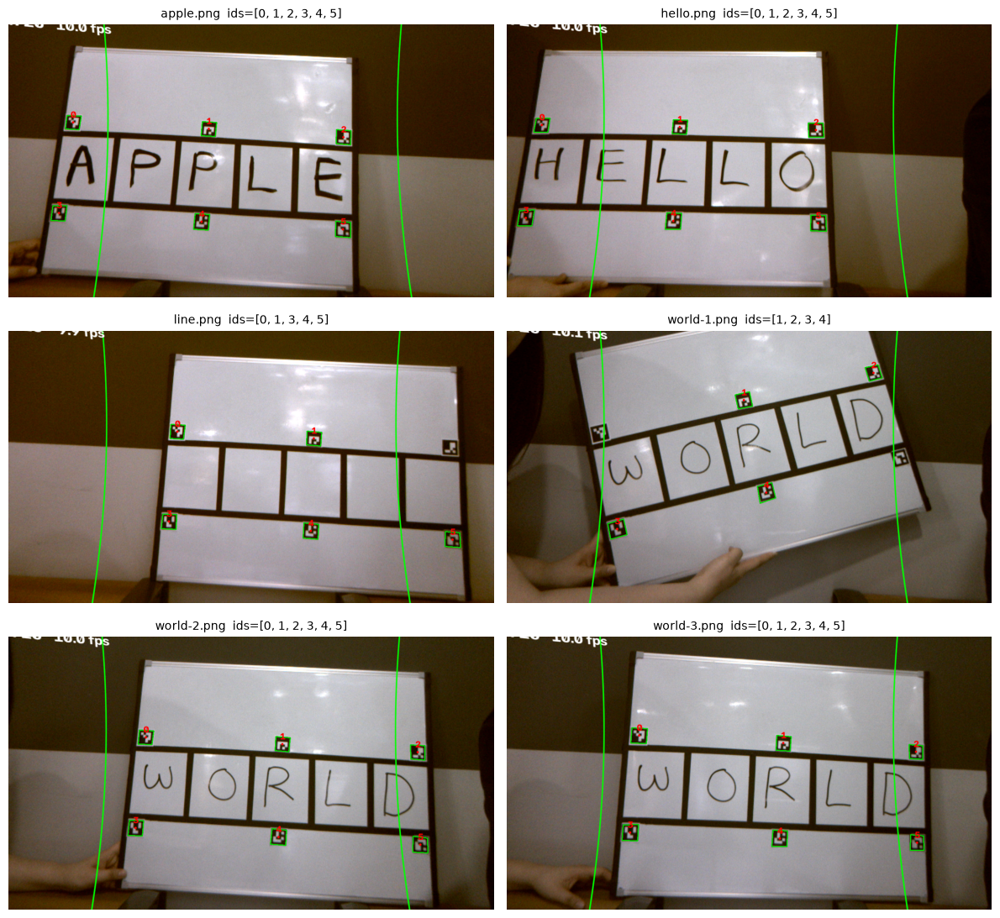

In [9]:
def draw_markers(bgr, found):
    """검출된 마커를 이미지 위에 표시"""
    v = bgr.copy()
    for mid, m in sorted(found.items()):
        p = m["p"].astype(np.int32)
        cv2.polylines(v, [p], True, (0, 220, 0), 2)
        c = m["c"].astype(int)
        cv2.circle(v, tuple(c), 3, (0, 0, 255), -1)
        cv2.putText(v, str(mid), (c[0] - 6, c[1] - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    return v


def show(imgs, titles, cols=2, size=6, gray=False):
    """이미지 여러 장을 제목과 함께 격자로 표시"""
    n = len(imgs)
    rows_ = (n + cols - 1) // cols
    fig, ax = plt.subplots(rows_, cols, figsize=(size * cols, size * rows_ * 0.62))
    ax = np.atleast_1d(ax).ravel()
    for a in ax:
        a.axis("off")
    for a, im, t in zip(ax, imgs, titles):
        a.imshow(im if gray else cv2.cvtColor(im, cv2.COLOR_BGR2RGB),
                 cmap="gray" if gray else None)
        a.set_title(t, fontsize=10)
    plt.tight_layout()
    plt.show()


vis, tit = [], []
for path in IMAGES:
    bgr = load_frame(path)
    f = detect(to_gray(bgr))
    vis.append(draw_markers(bgr, f))
    tit.append("%s  ids=%s" % (os.path.basename(path).replace("aru_test_img_", ""), sorted(f)))
show(vis, tit)

- 검출된 마커: 초록 사각형
- id: 숫자
- 마커 중심: 빨간 점

## 3. 보드 좌표계

- 마커 중심의 보드 좌표(`BOARD`)와 검출된 이미지 좌표를 짝지어 '보드 좌표 -> 이미지 좌표' 변환 구하기
- 변환을 통해서 칸 안의 한 점이 원본 이미지의 어디인지 알 수 있으므로, 그 점을 읽어 정면에서 본 이미지를 만들 수 있음

In [10]:
def board_to_image(found):
    """마커 위치로 보드 -> 이미지 homography 두 개(왼쪽, 오른쪽 조각) 계산

    return: HL, HR, centres, note
    """
    have = sorted(found)
    if len(have) < 4:
        return None, None, None, "마커 %d개 뿐 (최소 4개)" % len(have)

    src = np.float32([BOARD[i] for i in have])
    dst = np.float32([found[i]["c"] for i in have])
    H, _ = cv2.findHomography(src, dst, 0)     # 0 = 최소제곱
    if H is None:
        return None, None, None, "homography 계산 실패"

    # 빠진 마커는 위 변환으로 위치 추정
    centres, filled = {}, []
    for mid in BOARD:
        if mid in found:
            centres[mid] = found[mid]["c"]
        else:
            p = cv2.perspectiveTransform(np.float32([[BOARD[mid]]]), H)[0][0]
            centres[mid] = p
            filled.append(mid)

    def quad(ids):
        """마커 4개 대응으로 homography 하나 계산"""
        return cv2.getPerspectiveTransform(
            np.float32([BOARD[i] for i in ids]),
            np.float32([centres[i] for i in ids]))

    HL = quad((0, 1, 4, 3))
    HR = quad((1, 2, 5, 4))
    note = "마커 %d개" % len(have)
    if filled:
        note += ", id %s 는 추정" % ",".join(str(i) for i in filled)
    return HL, HR, centres, note


for path in IMAGES:
    f = detect(to_gray(load_frame(path)))
    _, _, _, note = board_to_image(f)
    print("%-26s %s" % (os.path.basename(path).replace("aru_test_img_", ""), note))

apple.png                  마커 6개
hello.png                  마커 6개
line.png                   마커 5개, id 2 는 추정
world-1.png                마커 4개, id 0,5 는 추정
world-2.png                마커 6개
world-3.png                마커 6개


## 4. 보드 기하 상수

2번 셀의 `MARK_X_SIDE`, `MARK_Y_TOP`, `MARK_Y_BOT` 은 실측값

1. 마커 네 개(한쪽 절반)를 정사각형으로 보내는 homography를 생성 - 칸 위치를 전혀 가정하지 않음
2. 편 이미지에서 세로 방향으로 어두운 줄이 어디 있는지 찾음 - 그 줄이 칸을 나누는 검은 선
3. 칸 5개가 같은 너비라는 조건을 걸고 최소제곱으로 맞춘다

아래 셀이 그 측정을 다시 돌린다. 보드를 새로 인쇄하면 이 셀을 돌려 상수를 갱신

In [11]:
def dark_line_centres(profile, frac=0.45):
    """밝기 프로파일에서 어두운 띠의 중심 위치 검출"""
    lo, hi = float(profile.min()), float(profile.max())
    dark = profile < lo + (hi - lo) * frac
    out, start = [], None
    for i, v in enumerate(dark):
        if v and start is None:
            start = i
        if not v and start is not None:
            out.append((start + i - 1) / 2.0)
            start = None
    if start is not None:
        out.append((start + len(dark) - 1) / 2.0)
    return out


def measure_half(gray, centres, ids, size=600):
    """보드 반쪽을 정사각형으로 펴서 칸 사이 검은 선 위치 측정 (0~1)

    return: v_lines, h_lines, warped
    """
    M = cv2.getPerspectiveTransform(
        np.float32([centres[i] for i in ids]),
        np.float32([[0, 0], [size, 0], [size, size], [0, size]]))
    w = cv2.warpPerspective(gray, M, (size, size))
    band_v = w[int(size * 0.35):int(size * 0.65)].mean(axis=0)
    band_h = w[:, int(size * 0.35):int(size * 0.65)].mean(axis=1)
    return ([x / size for x in dark_line_centres(band_v)],
            [y / size for y in dark_line_centres(band_h)],
            w)


obs_v, obs_h = [], []
for path in IMAGES:
    gray = to_gray(load_frame(path))
    f = detect(gray)
    if len(f) < 6:
        continue                      # 추정 마커 프레임 제외
    c = {i: f[i]["c"] for i in f}
    for tag, ids in (("L", (0, 1, 4, 3)), ("R", (1, 2, 5, 4))):
        v, h, _ = measure_half(gray, c, ids)
        # 칸 경계 두 개만 남김
        inner = [x for x in v if 0.15 < x < 0.90]
        if tag == "R":
            inner = [1 - x for x in inner][::-1]   # 좌우 반전해 왼쪽 기준으로
        if len(inner) == 2:
            obs_v.append(inner)
        edges = [y for y in h if 0.05 < y < 0.98]
        if len(edges) >= 2:
            obs_h.append([edges[0], edges[-1]])

obs_v = np.array(obs_v)
obs_h = np.array(obs_h)
if len(obs_v) == 0 or len(obs_h) == 0:
    print('측정에 쓸 수 있는 프레임이 없음') # 마커 6개가 모두 검출되고 칸 경계선이 각 반쪽에서 정확히 2개 잡힌 프레임이 필요
else:
    print("칸 경계 관측 %d쌍, 평균 %.4f / %.4f" % (len(obs_v), obs_v[:, 0].mean(), obs_v[:, 1].mean()))
    print("줄 상하단 관측 %d쌍, 평균 %.4f / %.4f" % (len(obs_h), obs_h[:, 0].mean(), obs_h[:, 1].mean()))

    # 조건: 칸 너비 w 동일, 마커 중심 간격 2.5칸
    # 왼쪽 끝 e = 1 - 2.5w, 경계는 e+w, e+2w
    b1, b2 = obs_v[:, 0].mean(), obs_v[:, 1].mean()
    w_fit = (3 * (1 - b1) + (1 - b2)) / 5.0
    e_fit = 1 - 2.5 * w_fit
    print()
    print("   칸 너비 w = %.4f (마커 간격 기준), 보드 왼쪽 끝 = %.4f" % (w_fit, e_fit))
    print("   -> MARK_X_SIDE = %.4f" % (-e_fit / w_fit))

    top, bot = obs_h[:, 0].mean(), obs_h[:, 1].mean()
    cell_h = bot - top
    print("   칸 높이 = %.4f (마커 간격 기준)" % cell_h)
    print("   -> MARK_Y_TOP = %.4f, MARK_Y_BOT = %.4f" % (-top / cell_h, (1 - bot) / cell_h + 1))
    print()
    print("2번 셀의 상수와 비교해서 크게 다르면 상수를 갱신할 것")

측정에 쓸 수 있는 프레임이 없음


## 5. 칸 잘라내기

출력 픽셀마다 원본의 어느 위치에서 가져올지 계산하는 역방향 매핑이다.
중간 이미지를 만들지 않으므로 보간이 한 번만 일어난다. 두 번 겹치면
그만큼 흐려진다.

칸 2번은 이음매를 걸치므로 왼쪽 절반과 오른쪽 절반을 각각 펴서 붙인다.

### 칸 자르기 실행

`cell_rect`, `warp_region`, `extract_cells`, `process` 정의, 시험 사진 6장에 실행해 `res` 생성

In [12]:
def cell_rect(k):
    """칸 k의 보드 좌표 범위 (좌우는 CELL_X 안쪽에서 MARGIN_X만큼 물러남)

    return: x0, y0, x1, y1
    """
    x0, x1 = CELL_X[k][0] + MARGIN_X, CELL_X[k][1] - MARGIN_X
    y0, y1 = INSET, 1 - INSET
    return x0, y0, x1, y1


def warp_region(img, H, x0, y0, x1, y1, w, h):
    """보드 좌표의 직사각형 영역 하나를 w x h 정면 이미지로 변환"""
    src = np.float32([[x0, y0], [x1, y0], [x1, y1], [x0, y1]])
    dst = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    # 출력 -> 이미지 변환 = H · (보드 -> 출력 변환)의 역
    M = H @ np.linalg.inv(cv2.getPerspectiveTransform(src, dst))
    return cv2.warpPerspective(img, M, (w, h),
                               flags=cv2.WARP_INVERSE_MAP | cv2.INTER_LINEAR,
                               borderMode=cv2.BORDER_REPLICATE)


def extract_cells(img, HL, HR, n=OUT_N):
    """칸 5개를 n x n 컬러 이미지로 잘라냄

    return: cells
    """
    cells = []
    for k in range(NUM_CELLS):
        x0, y0, x1, y1 = cell_rect(k)
        if x1 <= SEAM_X:
            cells.append(warp_region(img, HL, x0, y0, x1, y1, n, n))
        elif x0 >= SEAM_X:
            cells.append(warp_region(img, HR, x0, y0, x1, y1, n, n))
        else:
            # 이음매를 걸친 칸, 출력 폭을 비율대로 나눔
            cut = int(round(n * (SEAM_X - x0) / (x1 - x0)))
            left = warp_region(img, HL, x0, y0, SEAM_X, y1, cut, n)
            right = warp_region(img, HR, SEAM_X, y0, x1, y1, n - cut, n)
            cells.append(np.hstack([left, right]))
    return cells


def process(path):
    """사진 한 장의 마커 검출부터 칸 자르기까지 실행

    return: dict(bgr, gray, found, note, cells, centres, HL, HR)
    """
    bgr = load_frame(path)
    gray = to_gray(bgr)
    found = detect(gray)
    HL, HR, centres, note = board_to_image(found)
    if HL is None:
        return dict(bgr=bgr, gray=gray, found=found, note=note, cells=None, centres=None)
    return dict(bgr=bgr, gray=gray, found=found, note=note,
                cells=extract_cells(bgr, HL, HR), centres=centres,
                HL=HL, HR=HR)


res = {os.path.basename(p).replace("aru_test_img_", "").replace(".png", ""): process(p)
       for p in IMAGES}
for k, v in res.items():
    print("%-10s %s" % (k, v["note"]))

apple      마커 6개
hello      마커 6개
line       마커 5개, id 2 는 추정
world-1    마커 4개, id 0,5 는 추정
world-2    마커 6개
world-3    마커 6개


### 칸 좌우 범위 재측정

칸 양옆의 검은 선이 보드 좌표 어디에 있는지 재서 `CELL_X` 를 구한다. 칸 k 의 안쪽 범위는 (k 번째 선의 끝, k+1 번째 선의 시작) 이다.

1절의 `CELL_X` 와 크게 다르면 그 값으로 갱신한다. 캘리브레이션 결과를 새로 만들었거나 `BOARD` 를 고쳤다면 이 셀을 다시 돌려야 한다.

In [13]:
def board_strip(r, ppu=200, y_lo=0.20, y_hi=0.90, x_lo=-0.4, x_hi=5.4):
    """보드 좌표 격자를 이미지에서 샘플링해 정면 띠 생성

    return: strip, xs
    """
    xs = np.linspace(x_lo, x_hi, int((x_hi - x_lo) * ppu))
    ys = np.linspace(y_lo, y_hi, int((y_hi - y_lo) * ppu))
    X, Y = np.meshgrid(xs, ys)
    pts = np.stack([X.ravel(), Y.ravel()], 1).astype(np.float32).reshape(-1, 1, 2)
    m = np.zeros((len(pts), 2), np.float32)
    left = X.ravel() <= SEAM_X
    for sel, H in ((left, r["HL"]), (~left, r["HR"])):
        m[sel] = cv2.perspectiveTransform(pts[sel], H).reshape(-1, 2)
    strip = cv2.remap(r["gray"], m[:, 0].reshape(X.shape), m[:, 1].reshape(X.shape),
                      cv2.INTER_LINEAR, borderValue=255)
    return strip, xs


def vertical_lines(r):
    """정면 띠에서 칸 양옆 검은 선 6개의 (시작, 끝) 검출, 못 찾으면 None

    return: lines
    """
    strip, xs = board_strip(r)
    prof = strip.mean(axis=0)
    dark = prof < prof.min() + (np.percentile(prof, 90) - prof.min()) * 0.5
    runs, s = [], None
    for i, v in enumerate(dark):
        if v and s is None:
            s = i
        if not v and s is not None:
            runs.append((xs[s], xs[i - 1]))
            s = None
    if s is not None:
        runs.append((xs[s], xs[-1]))
    runs = [q for q in runs if q[1] - q[0] > 0.03]        # 가는 획 제외
    lines = []
    for j in range(NUM_CELLS + 1):                        # j 번째 선은 x = j 근처
        near = [q for q in runs if abs((q[0] + q[1]) / 2 - j) < 0.3]
        if not near:
            return None
        lines.append(min(near, key=lambda q: abs((q[0] + q[1]) / 2 - j)))
    return lines


spans = []
print("프레임별 칸 안쪽 가로 범위 (왼쪽 선의 끝, 오른쪽 선의 시작)")
for name, r in res.items():
    if r["cells"] is None or len(r["found"]) < 6:
        continue                                          # 추정 마커 프레임 제외
    L = vertical_lines(r)
    if L is None:
        print("   %-8s 검은 선 6개를 못 찾음" % name)
        continue
    e = [(L[k][1], L[k + 1][0]) for k in range(NUM_CELLS)]
    spans.append(e)
    print("   %-8s " % name + " ".join("(%.3f, %.3f)" % x for x in e))

A = np.array(spans)
med, sd = np.median(A, axis=0), A.std(axis=0)
print()
print("중앙값     " + " ".join("(%.3f, %.3f)" % tuple(x) for x in med))
print("표준편차   " + " ".join("(%.3f, %.3f)" % tuple(x) for x in sd))
print("MARGIN_X = %.3f 는 표준편차의 최대 %.3f 보다 커야 한다" % (MARGIN_X, sd.max()))
print()
print("CELL_X   = [" + ", ".join("(%.3f, %.3f)" % tuple(x) for x in med) + "]")
print("(현재)   = [" + ", ".join("(%.3f, %.3f)" % x for x in CELL_X) + "]")

프레임별 칸 안쪽 가로 범위 (왼쪽 선의 끝, 오른쪽 선의 시작)
   apple    (0.105, 0.976) (1.066, 1.987) (2.077, 2.958) (3.063, 3.919) (4.019, 4.910)
   hello    (0.110, 0.976) (1.071, 1.987) (2.077, 2.958) (3.058, 3.914) (4.019, 4.910)
   world-2  (0.100, 0.971) (1.061, 1.982) (2.072, 2.958) (3.058, 3.914) (4.019, 4.905)
   world-3  (0.100, 0.971) (1.061, 1.982) (2.067, 2.953) (3.058, 3.909) (4.019, 4.900)

중앙값     (0.103, 0.974) (1.064, 1.985) (2.075, 2.958) (3.058, 3.914) (4.019, 4.907)
표준편차   (0.004, 0.003) (0.004, 0.003) (0.004, 0.002) (0.002, 0.004) (0.000, 0.004)
MARGIN_X = 0.025 는 표준편차의 최대 0.004 보다 커야 한다

CELL_X   = [(0.103, 0.974), (1.064, 1.985), (2.075, 2.958), (3.058, 3.914), (4.019, 4.907)]
(현재)   = [(0.095, 0.956), (1.046, 1.987), (2.072, 2.970), (3.073, 3.946), (4.056, 4.915)]


### 잘라낸 위치가 맞는지 원본 위에 그려 확인

파란 선이 칸 경계, 노란 선이 실제로 잘라낸 범위(INSET 적용), 빨간 선이
왼쪽/오른쪽 절반의 이음매다.

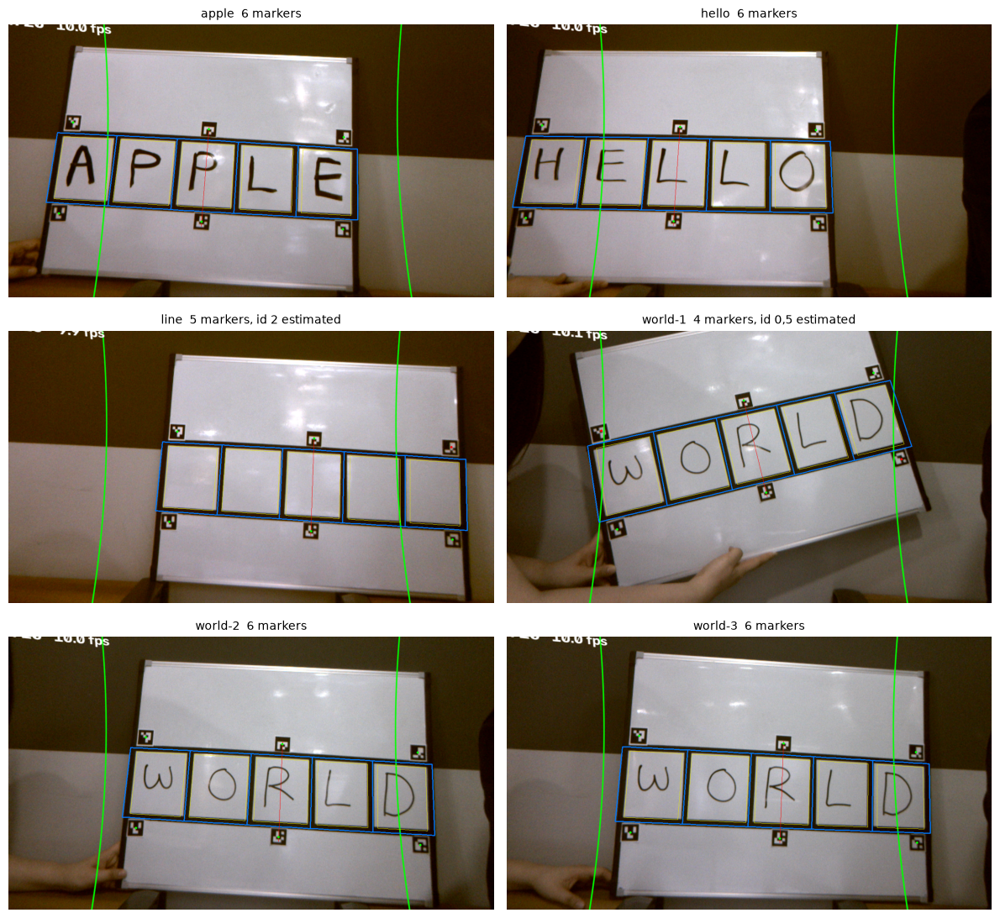

In [14]:
def overlay(r):
    """잘라내는 범위와 칸 경계를 원본 이미지 위에 표시"""
    v = r["bgr"].copy()
    if r["cells"] is None:
        return v
    HL, HR = r["HL"], r["HR"]

    def px(x, y):
        """보드 좌표를 이미지 픽셀로 변환"""
        H = HL if x <= SEAM_X else HR
        p = cv2.perspectiveTransform(np.float32([[[x, y]]]), H)[0][0]
        return tuple(np.round(p).astype(int))

    def poly(pts, color, th=2):
        """점들을 이어 닫힌 선으로 표시"""
        cv2.polylines(v, [np.array(pts, np.int32)], True, color, th)

    steps = 12
    for k in range(NUM_CELLS):                      # 칸 경계
        poly([px(k + t / steps, 0) for t in range(steps + 1)]
             + [px(k + 1 - t / steps, 1) for t in range(steps + 1)], (255, 120, 0), 2)
        x0, y0, x1, y1 = cell_rect(k)               # 실제 잘라낸 범위
        poly([px(x0 + (x1 - x0) * t / steps, y0) for t in range(steps + 1)]
             + [px(x1 - (x1 - x0) * t / steps, y1) for t in range(steps + 1)], (0, 230, 230), 1)
    cv2.line(v, px(SEAM_X, -0.2), px(SEAM_X, 1.2), (0, 0, 255), 1)
    for mid, c in r["centres"].items():
        cv2.circle(v, tuple(np.round(c).astype(int)), 3,
                   (0, 255, 0) if mid in r["found"] else (0, 0, 255), -1)
    return v


def note_en(r):
    """그림 제목용 마커 개수 요약 (영어)"""
    if r["centres"] is None:
        return "not enough markers"
    est = [i for i in r["centres"] if i not in r["found"]]
    return "%d markers" % len(r["found"]) + ("" if not est else ", id %s estimated" % ",".join(str(x) for x in est))


show([overlay(r) for r in res.values()],
     ["%s  %s" % (k, note_en(r)) for k, r in res.items()])

### 잘라낸 칸 112x112

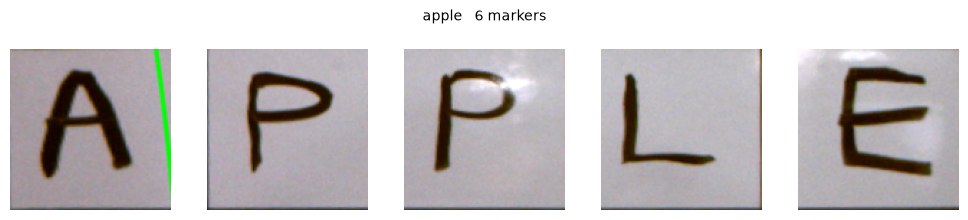

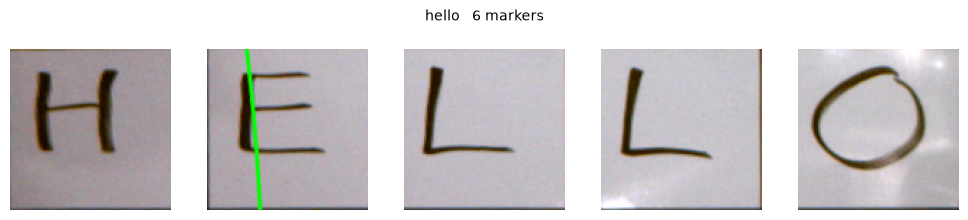

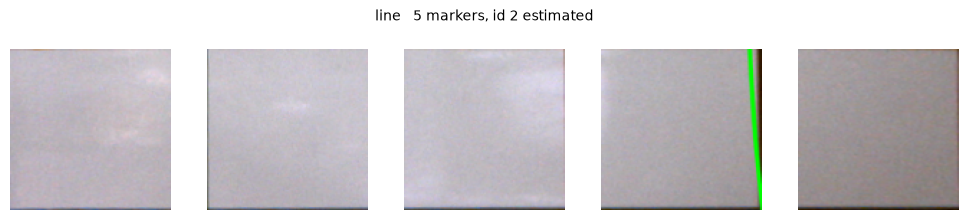

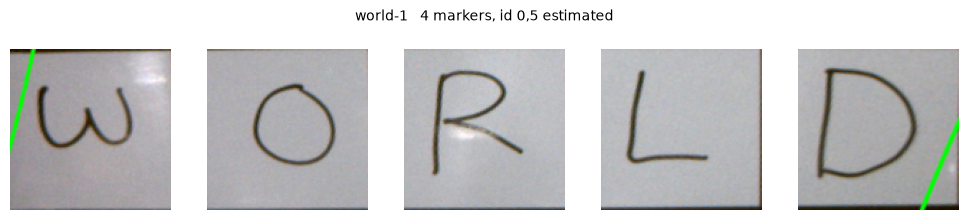

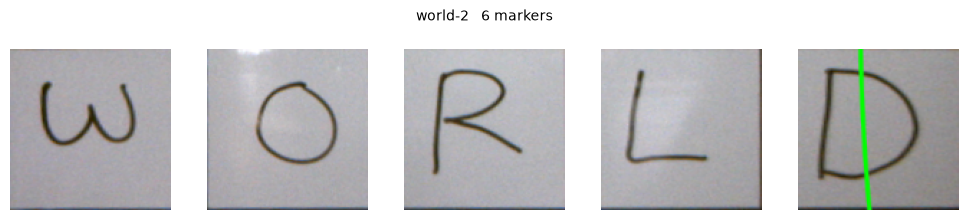

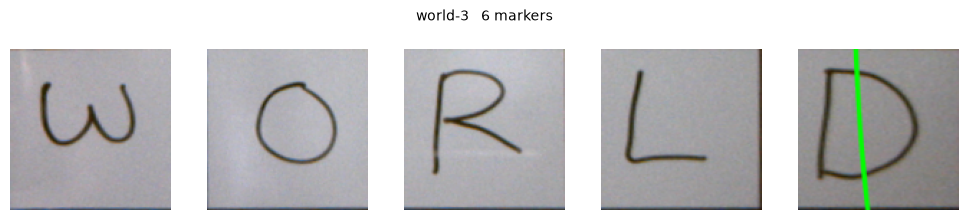

In [15]:
for name, r in res.items():
    if r["cells"] is None:
        print(name, "->", r["note"])
        continue
    fig, ax = plt.subplots(1, NUM_CELLS, figsize=(10, 2.2))
    for a, c in zip(ax, r["cells"]):
        a.imshow(cv2.cvtColor(c, cv2.COLOR_BGR2RGB))
        a.axis("off")
    fig.suptitle("%s   %s" % (name, note_en(r)), fontsize=10)
    plt.tight_layout()
    plt.show()

### 잘라낸 칸에 검은 테두리가 남았는지

칸의 네 변에서 안쪽으로 검은 선과 번진 자리가 몇 px 들어왔는지 잰다. 안쪽 밝기보다 4 % 넘게 어두운 열/행이 가장자리에서 몇 개 이어지는지 센다. 조명이 한쪽으로 기울어 있어도 안쪽 밝기를 기준으로 하니 따라간다. 0 이면 없는 것이고, 칸 한 변은 112 px 이다.

In [16]:
def border_depth(cell, tol=0.96, max_px=12):
    """칸 네 변에 검은 선과 번진 자국이 몇 px 들어왔는지 측정

    안쪽 밝기(가장자리 6~30 px의 75 백분위) 대비 tol 배 미만인 열/행이 가장자리에서 이어진 길이

    return: {위, 아래, 왼, 오른}
    """
    g = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY).astype(np.float32)

    def run(prof):
        """가장자리부터 어두운 구간이 몇 칸 이어지는지 계산"""
        ref = np.percentile(prof[6:30], 75)
        n = 0
        while n < max_px and prof[n] < tol * ref:
            n += 1
        return n

    rows_, cols_ = g.mean(axis=1), g.mean(axis=0)
    return {"위": run(rows_), "아래": run(rows_[::-1]), "왼": run(cols_), "오른": run(cols_[::-1])}


worst = 0
print("%-10s %-4s %s" % ("image", "칸", "위 / 아래 / 왼 / 오른 (px)"))
for name, r in res.items():
    if r["cells"] is None:
        continue
    for k, c in enumerate(r["cells"]):
        d = border_depth(c)
        worst = max(worst, max(d.values()))
        if max(d.values()) > 0:
            print("%-10s %-4d %3d / %3d / %3d / %3d" % (name, k, d["위"], d["아래"], d["왼"], d["오른"]))
print()
print("가장 깊이 들어온 검은 선: %d px %s" % (worst, "(테두리 없음)" if worst == 0 else ""))

image      칸    위 / 아래 / 왼 / 오른 (px)
apple      0      1 /   3 /   1 /   0
apple      1      0 /   3 /   2 /   0
apple      2      0 /   3 /   0 /   1
apple      3      0 /   3 /   0 /   2
apple      4      0 /   3 /   0 /   2
hello      0      1 /   3 /   1 /   0
hello      1      0 /   3 /   3 /   0
hello      2      0 /   3 /   0 /   0
hello      3      0 /   2 /   0 /   3
hello      4      0 /   3 /   0 /   7
line       0      1 /   2 /   0 /   0
line       1      0 /   3 /   2 /   0
line       2      1 /   3 /   0 /   1
line       3      0 /   5 /   0 /   9
line       4      1 /   4 /   0 /   3
world-1    0      4 /   2 /   1 /   3
world-1    1      2 /   2 /   0 /   0
world-1    2      0 /   3 /   0 /   0
world-1    3      0 /   4 /   0 /   3
world-1    4      0 /   5 /   0 /   2
world-2    0      1 /   3 /   0 /   0
world-2    1      0 /   3 /  12 /   0
world-2    2      0 /   3 /   0 /   0
world-2    3      0 /   4 /   0 /   3
world-2    4      1 /   3 /   0 /   2
world-3    0 

### 캘리브레이션 전후 비교

같은 시험 사진을 캘리브레이션 없이 잘랐을 때와 캘리브레이션 후에 잘랐을 때를 나란히 본다. 공정하게 비교하려고 두 경우 모두 칸 좌우 범위(`CELL_X`)를 그 조건에서 다시 잰다.

- 위 줄: 캘리브레이션 전 (원본 프레임)
- 아래 줄: 캘리브레이션 후 (렌즈 왜곡을 편 프레임)

표는 세 가지를 비교한다.

| 항목 | 뜻 |
| --- | --- |
| 칸 범위 표준편차 | 프레임마다 잰 칸 좌우 범위가 얼마나 흔들리는가. 작을수록 보드 위치와 무관하게 같은 곳을 자른다 |
| 가장자리 검은 선 | 잘라낸 칸의 네 변에 검은 선과 번진 자리가 평균 몇 px 들어왔는가. 자르기(trim) 전 상태끼리 비교한다 |
| 마커 잔차 | 마커 6개를 homography 하나로 맞췄을 때 남는 어긋남. 렌즈 왜곡이 남아 있을수록 크다 |

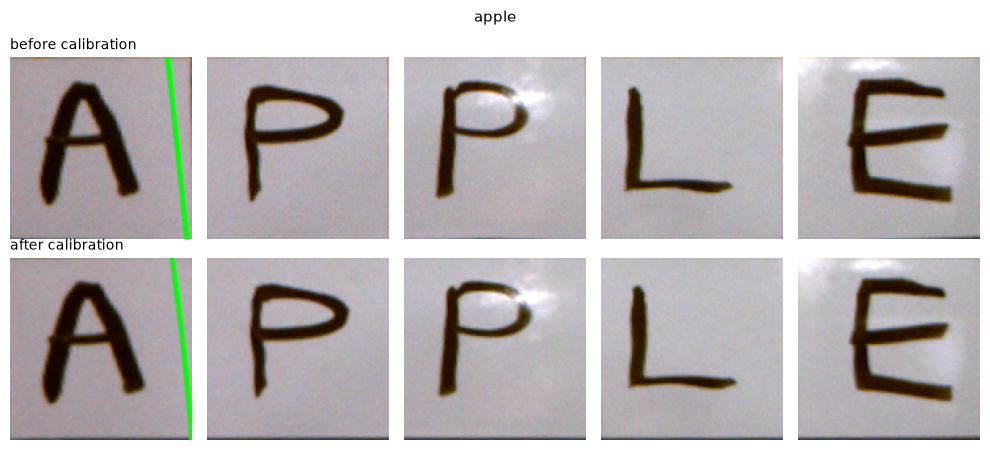

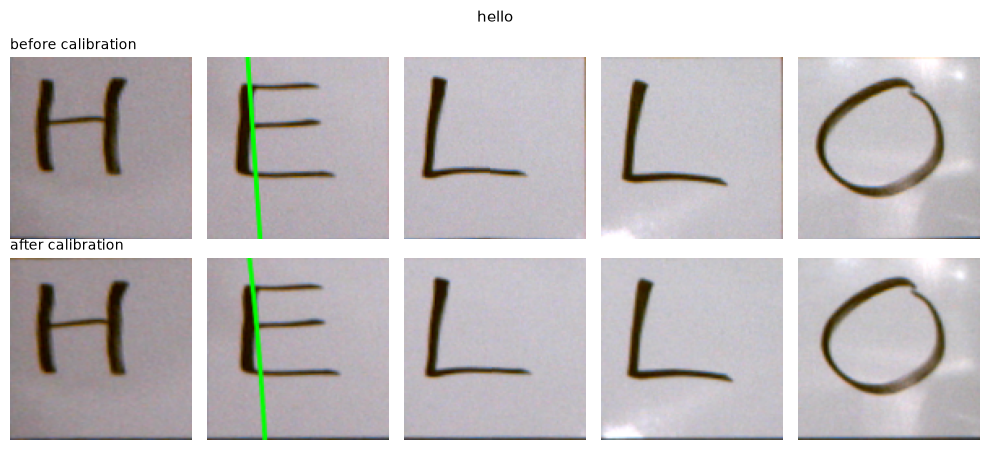

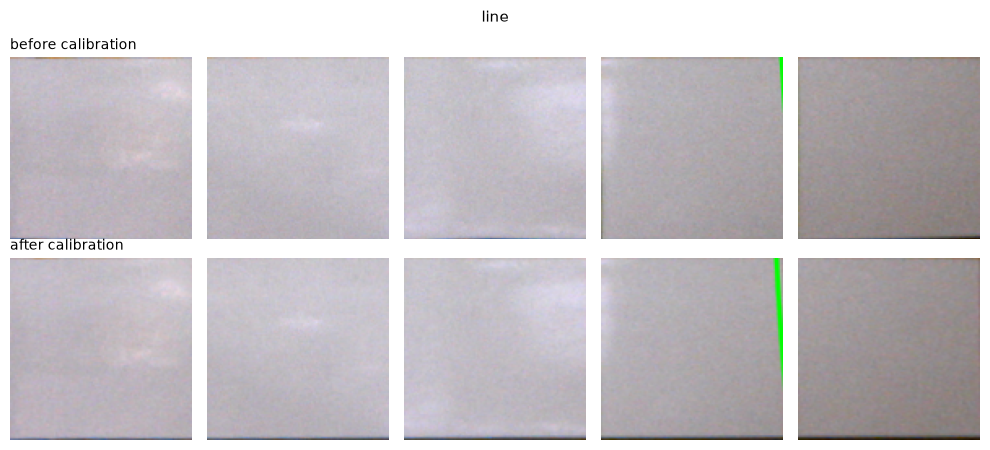

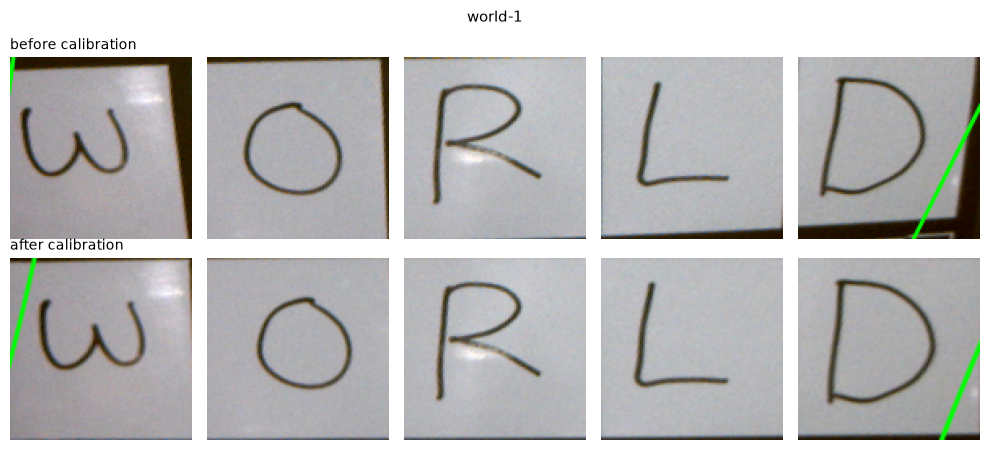

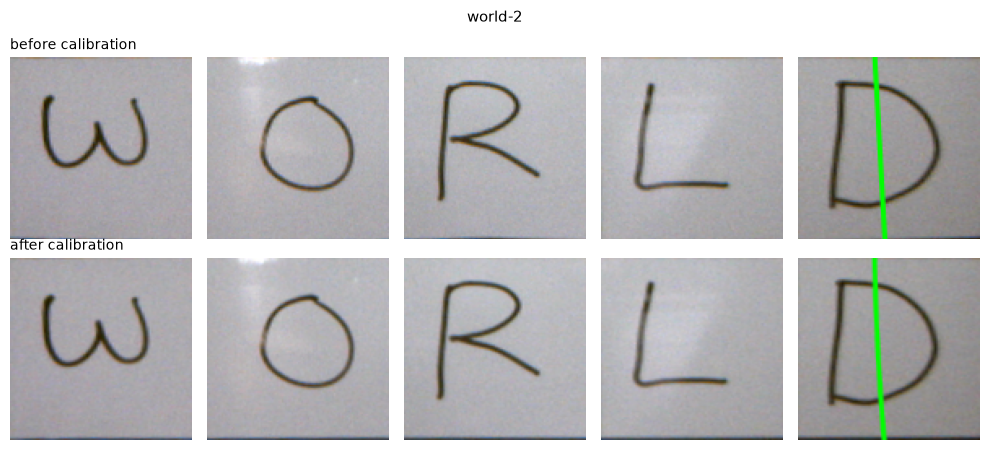

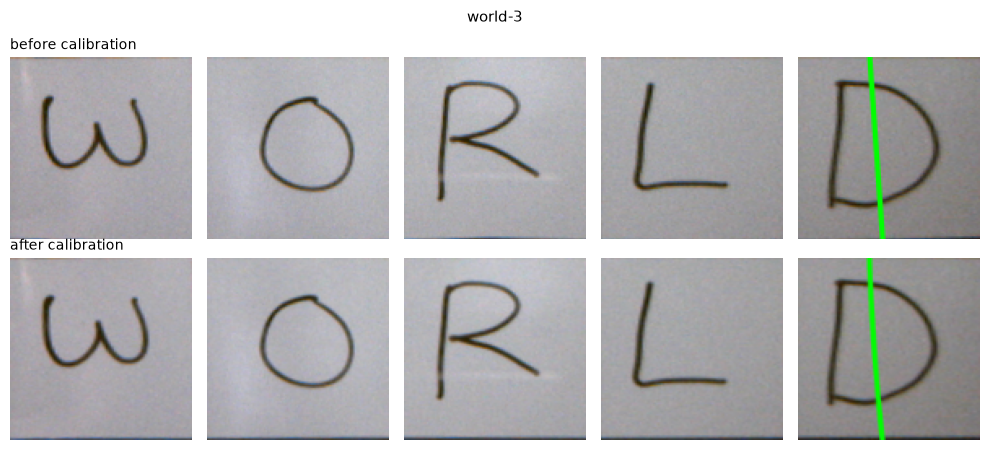

           칸 범위 표준편차          가장자리 검은 선(4변 평균)         마커 잔차
보정 전       0.013 칸            평균 1.4 (최대 12) px 5.62 px
보정 후       0.004 칸            평균 1.3 (최대 12) px 1.16 px

CELL_X 보정 전 = [(0.095, 0.956), (1.046, 1.987), (2.072, 2.97), (3.073, 3.946), (4.056, 4.915)]
CELL_X 보정 후 = [(0.103, 0.974), (1.064, 1.985), (2.075, 2.958), (3.058, 3.914), (4.019, 4.907)]
(현재 3번 셀) = [(0.095, 0.956), (1.046, 1.987), (2.072, 2.97), (3.073, 3.946), (4.056, 4.915)]


In [17]:
def run_variant(use_calib):
    """calibration 사용 여부만 바꿔 전체 과정 재실행 (CELL_X도 다시 측정, 끝나면 복원)

    return: out, CELL_X, sd
    """
    global K, CELL_X
    saved_K, saved_X = K, CELL_X
    if not use_calib:
        K = None
    try:
        out = {os.path.basename(p).replace("aru_test_img_", "").replace(".png", ""): process(p)
               for p in IMAGES}
        spans = []
        for r in out.values():
            if r["cells"] is None or len(r["found"]) < 6:
                continue
            L = vertical_lines(r)
            if L is not None:
                spans.append([(L[k][1], L[k + 1][0]) for k in range(NUM_CELLS)])
        sd = float("nan")
        if spans:
            A = np.array(spans)
            CELL_X = [tuple(x) for x in np.median(A, axis=0)]
            sd = float(A.std(axis=0).max())
            for r in out.values():
                if r["cells"] is not None:
                    r["cells"] = extract_cells(r["bgr"], r["HL"], r["HR"])
        return out, list(CELL_X), sd
    finally:
        K, CELL_X = saved_K, saved_X


def marker_residual(found):
    """마커 6개를 homography 하나로 맞췄을 때 잔차(px, rms), 6개가 아니면 None"""
    if len(found) < 6:
        return None
    src_ = np.float32([BOARD[i] for i in range(6)])
    dst_ = np.float32([found[i]["c"] for i in range(6)])
    H_, _ = cv2.findHomography(src_, dst_, 0)
    pr = cv2.perspectiveTransform(src_.reshape(-1, 1, 2), H_).reshape(-1, 2)
    return float(np.sqrt(((pr - dst_) ** 2).sum(1).mean()))


if K is None:
    print("캘리브레이션 결과가 없어 비교할 수 없다 (calib/ 에 사진을 넣고 1-1절을 다시 실행)")
else:
    before, x_before, sd_before = run_variant(False)
    after, x_after, sd_after = run_variant(True)

    for name in after:
        if before[name]["cells"] is None or after[name]["cells"] is None:
            print("%-8s 마커가 부족해 한쪽을 자르지 못했다 (전 %s / 후 %s)"
                  % (name, before[name]["note"], after[name]["note"]))
            continue
        fig, ax = plt.subplots(2, NUM_CELLS, figsize=(10, 4.6))
        for j in range(NUM_CELLS):
            for i_, (lab, d) in enumerate((("전", before), ("후", after))):
                ax[i_, j].imshow(cv2.cvtColor(d[name]["cells"][j], cv2.COLOR_BGR2RGB))
                ax[i_, j].axis("off")
        ax[0, 0].set_title("before calibration", loc="left", fontsize=10)
        ax[1, 0].set_title("after calibration", loc="left", fontsize=10)
        fig.suptitle(name, fontsize=11)
        plt.tight_layout()
        plt.show()

    def border_stats(d):
        """모든 칸의 가장자리 검은 선 폭 평균, 최대"""
        v = []
        for r in d.values():
            if r["cells"] is not None:
                for c in r["cells"]:
                    v += list(border_depth(c).values())
        return float(np.mean(v)), max(v)

    def mean_residual(d):
        """여러 사진의 마커 잔차 평균"""
        v = [marker_residual(r["found"]) for r in d.values()]
        v = [x for x in v if x is not None]
        return float(np.mean(v)) if v else float("nan")

    print("%-10s %-18s %-24s %s" % ("", "칸 범위 표준편차", "가장자리 검은 선(4변 평균)", "마커 잔차"))
    for lab, d, sd_ in (("보정 전", before, sd_before), ("보정 후", after, sd_after)):
        m_, w_ = border_stats(d)
        print("%-10s %-18s %-16s %s" % (lab, "%.3f 칸" % sd_, "평균 %.1f (최대 %d) px" % (m_, w_), "%.2f px" % mean_residual(d)))
    print()
    print("CELL_X 보정 전 =", [tuple(round(float(v), 3) for v in x) for x in x_before])
    print("CELL_X 보정 후 =", [tuple(round(float(v), 3) for v in x) for x in x_after])
    print("(현재 3번 셀) =", [tuple(round(float(v), 3) for v in x) for x in CELL_X])

### 남은 검은 테두리 잘라내기

위 검사에서 검은 선이나 번진 가장자리가 남은 칸은, 남은 폭에 `TRIM_PAD` 를 더한 만큼 자르는 범위를 줄여서 원본에서 다시 자른다. 검은 선보다 2~3 px 더 안쪽에서 자르려는 것이다.

- 출력은 그대로 112x112 이다. 범위를 줄인 만큼 글자가 조금 커진다
- 검은 선이 없는 변은 그대로 둔다
- 한 변에서 줄이는 양은 `MAX_TRIM` 을 넘지 않는다. 글자를 자르지 않게 하는 안전장치다
- 자르기 전 칸은 `r["cells_raw"]` 에 남겨 둔다

줄인 범위 (px, 왼/오른/위/아래). 0 이면 손대지 않음
image      칸0 | 칸1 | 칸2 | 칸3 | 칸4
apple       3/ 0/ 3/ 5 |  4/ 0/ 0/ 5 |  0/14/ 0/ 5 |  0/ 4/ 0/ 5 |  0/ 4/ 0/ 5
hello       3/ 0/ 3/ 5 |  5/ 0/ 0/ 5 |  0/ 0/ 0/ 5 |  0/ 5/ 0/ 4 |  0/ 9/ 0/ 5
line        0/ 0/ 3/ 4 |  4/ 0/ 0/ 5 |  0/ 3/ 3/ 5 |  0/11/ 0/ 7 |  0/ 5/ 3/ 6
world-1     3/ 5/ 6/ 4 |  0/ 0/ 4/ 4 |  0/ 0/ 0/ 5 |  0/ 5/ 0/ 6 |  0/ 4/ 0/ 7
world-2     0/ 0/ 3/ 5 | 14/ 0/ 0/ 5 |  0/ 0/ 0/ 5 |  0/ 5/ 0/ 6 |  0/ 4/ 3/ 5
world-3     3/ 0/ 3/ 4 |  7/ 0/ 0/ 8 |  0/ 3/ 0/ 5 |  0/ 6/ 0/ 5 |  0/ 5/ 3/ 6

가장자리 검은 선 (4변 평균 / 최대): 자르기 전 1.6 / 12 px -> 후 0.1 / 7 px


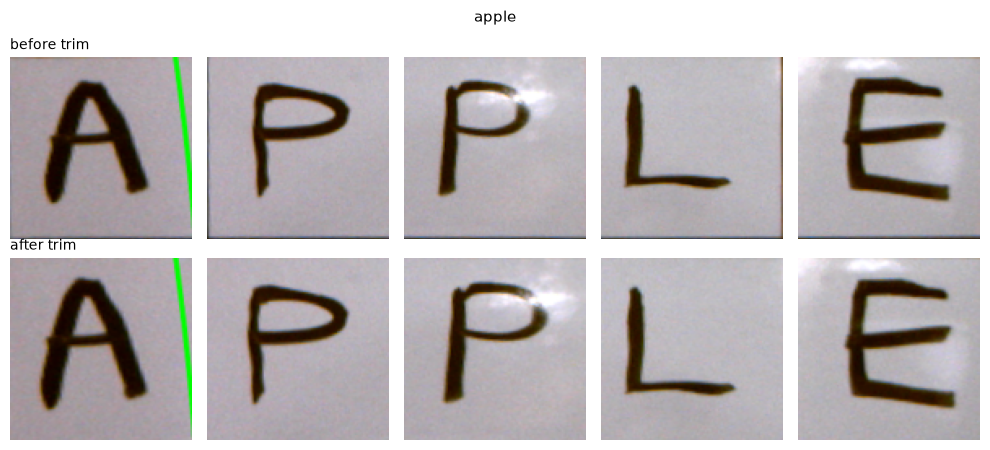

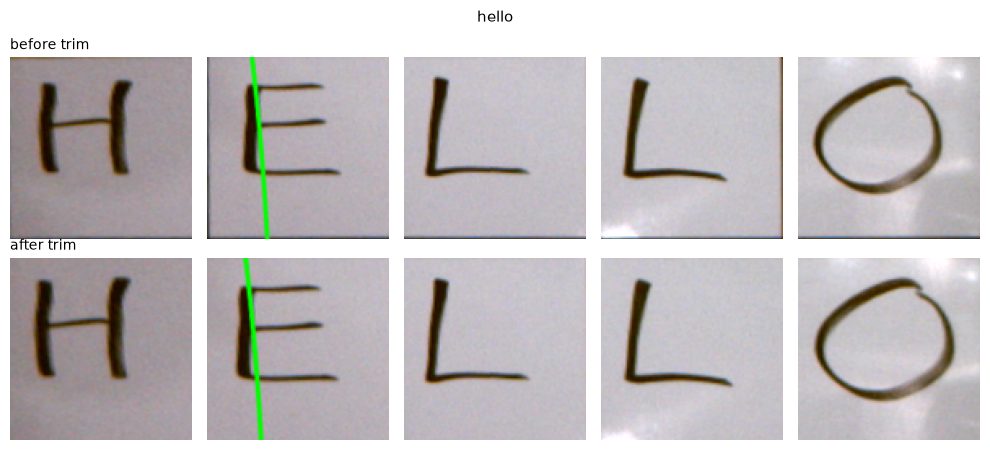

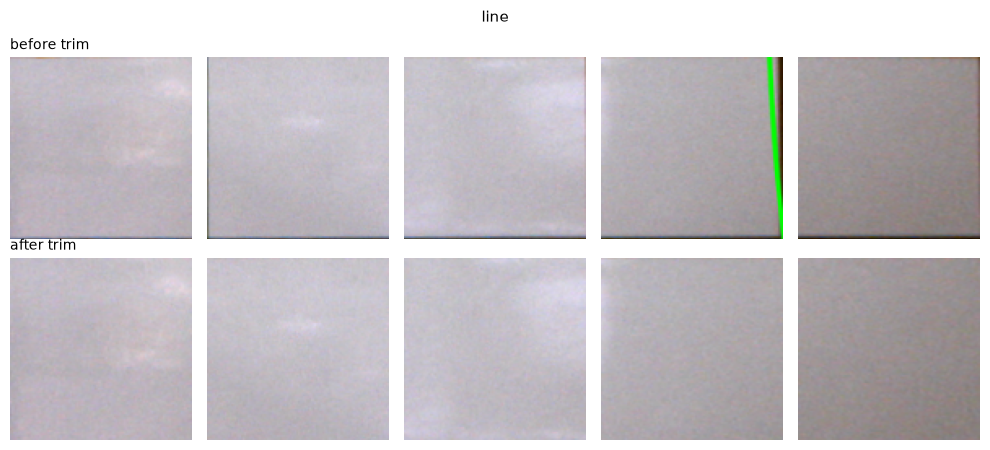

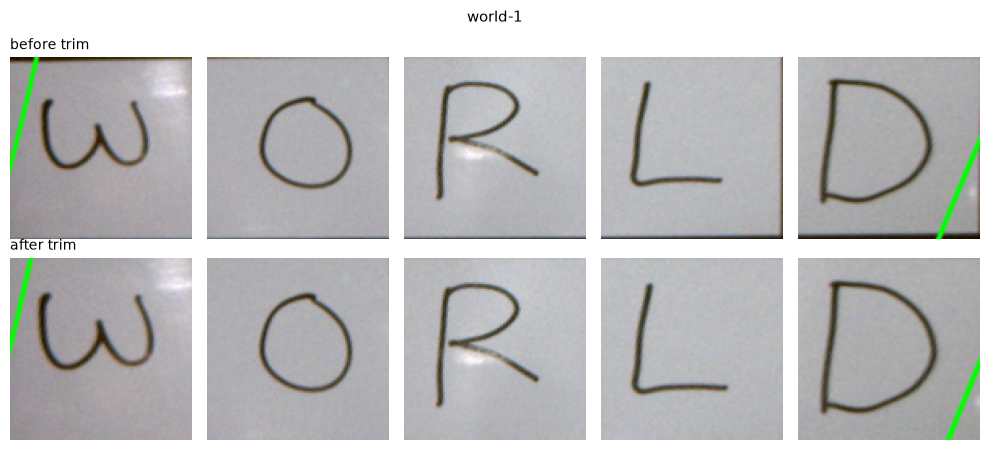

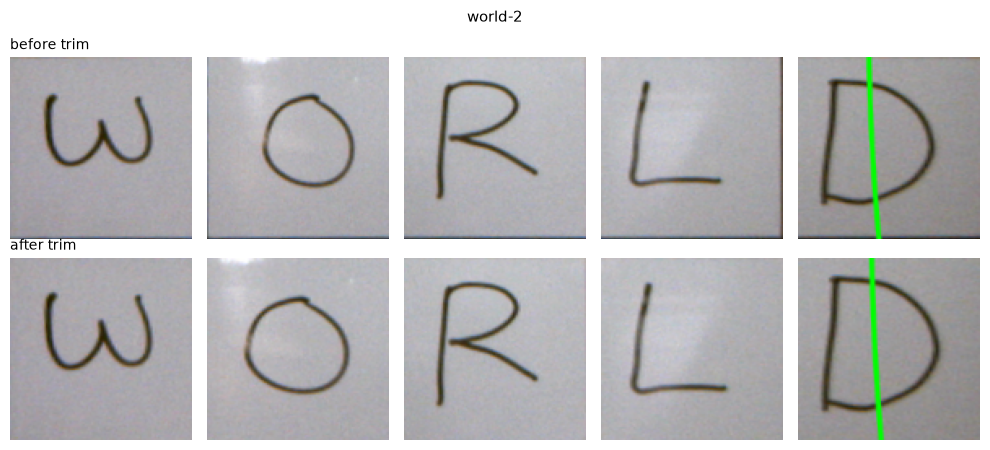

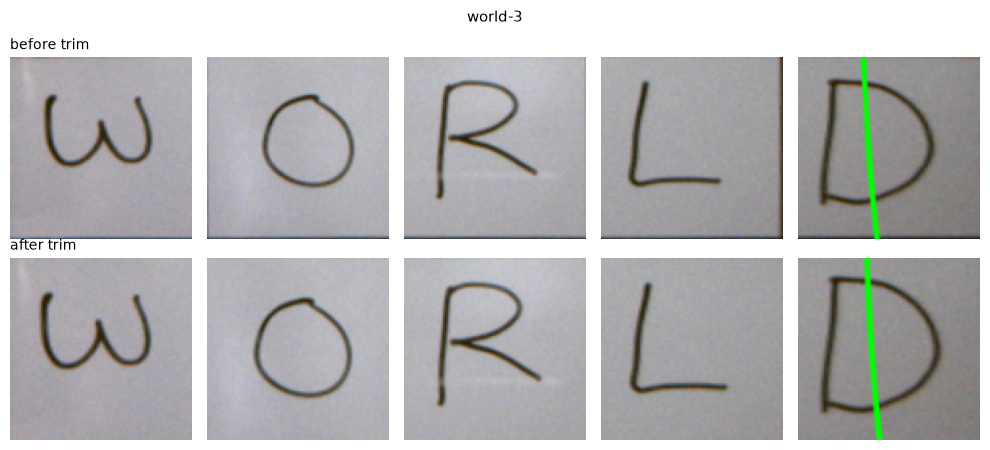

In [18]:
TRIM_PAD = 2      # 검은 선 끝에서 더 물러나는 px
MAX_TRIM = 14      # 한 변 최대 px


def warp_cell(img, HL, HR, rect, n=OUT_N):
    """보드 좌표 범위를 n x n 이미지로 변환 (이음매를 걸치면 좌우 조각 연결)"""
    x0, y0, x1, y1 = rect
    if x1 <= SEAM_X:
        return warp_region(img, HL, x0, y0, x1, y1, n, n)
    if x0 >= SEAM_X:
        return warp_region(img, HR, x0, y0, x1, y1, n, n)
    cut = int(round(n * (SEAM_X - x0) / (x1 - x0)))
    left = warp_region(img, HL, x0, y0, SEAM_X, y1, cut, n)
    right = warp_region(img, HR, SEAM_X, y0, x1, y1, n - cut, n)
    return np.hstack([left, right])


def trim_cell(img, HL, HR, rect, n=OUT_N, rounds=3):
    """가장자리에 검은 선이 남으면 그 폭 + TRIM_PAD만큼 범위를 줄여 다시 자름

    return: cell, total
    """
    x0, y0, x1, y1 = rect
    total = [0, 0, 0, 0]
    cell = warp_cell(img, HL, HR, (x0, y0, x1, y1), n)
    for _ in range(rounds):
        d = border_depth(cell)
        want = [d["왼"], d["오른"], d["위"], d["아래"]]
        cut = [min(w + TRIM_PAD, MAX_TRIM - t) if w > 0 else 0 for w, t in zip(want, total)]
        if not any(c > 0 for c in cut):
            break
        w_, h_ = x1 - x0, y1 - y0
        x0, x1 = x0 + cut[0] / n * w_, x1 - cut[1] / n * w_
        y0, y1 = y0 + cut[2] / n * h_, y1 - cut[3] / n * h_
        total = [a + b for a, b in zip(total, cut)]
        cell = warp_cell(img, HL, HR, (x0, y0, x1, y1), n)
    return cell, total


trim_log = {}
for name, r in res.items():
    if r["cells"] is None:
        continue
    r.setdefault("cells_raw", r["cells"])
    out, log_ = [], []
    for k in range(NUM_CELLS):
        c, tot = trim_cell(r["bgr"], r["HL"], r["HR"], cell_rect(k))
        out.append(c)
        log_.append(tot)
    r["cells"] = out
    trim_log[name] = log_

print("줄인 범위 (px, 왼/오른/위/아래). 0 이면 손대지 않음")
print("%-10s %s" % ("image", " | ".join("칸%d" % k for k in range(NUM_CELLS))))
for name, log_ in trim_log.items():
    print("%-10s %s" % (name, " | ".join("%2d/%2d/%2d/%2d" % tuple(t) for t in log_)))

def all_depths(key):
    """모든 칸의 네 변 검은 선 폭 목록"""
    return [v for r in res.values() if r["cells"] is not None for c in r[key] for v in border_depth(c).values()]


d_before, d_after = all_depths("cells_raw"), all_depths("cells")
print()
print("가장자리 검은 선 (4변 평균 / 최대): 자르기 전 %.1f / %d px -> 후 %.1f / %d px"
      % (np.mean(d_before), max(d_before), np.mean(d_after), max(d_after)))

for name, r in res.items():
    if r["cells"] is None:
        continue
    fig, ax = plt.subplots(2, NUM_CELLS, figsize=(10, 4.6))
    for j in range(NUM_CELLS):
        for i_, key in enumerate(("cells_raw", "cells")):
            ax[i_, j].imshow(cv2.cvtColor(r[key][j], cv2.COLOR_BGR2RGB))
            ax[i_, j].axis("off")
    ax[0, 0].set_title("before trim", loc="left", fontsize=10)
    ax[1, 0].set_title("after trim", loc="left", fontsize=10)
    fig.suptitle(name, fontsize=11)
    plt.tight_layout()
    plt.show()

## 6. 결과 저장

`out/` 에 칸 이미지를 PNG 로 남긴다.

In [19]:
for name, r in res.items():
    if r["cells"] is None:
        continue
    for k, c in enumerate(r["cells"]):
        cv2.imwrite(os.path.join(OUT_DIR, "%s_cell%d.png" % (name, k)), c)
print("saved to", OUT_DIR)

saved to /Users/mumallaeng/repo/activity/LightLetter-aruco-worktree/tb/aruco_crop/out
